In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__results__.html
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__huggingface_repos__.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__notebook__.ipynb
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/__output__.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/custom.css
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/config.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/training_args.bin
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/tokenizer.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/tokenizer_config.json
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/model.safetensors
/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm/checkpoint-24000/config.json
/kaggle/input/noteb

# NLI setup

In [26]:
CROISSANT_URL = "https://huggingface.co/api/datasets/persiannlp/parsinlu_entailment/croissant"

ds = Dataset(jsonld=CROISSANT_URL)

records = ds.records("parsinlu-repo")

print(records)


Records(dataset=Dataset(jsonld='https://huggingface.co/api/datasets/persiannlp/parsinlu_entailment/croissant', operations=OperationGraph(issues=Issues(_errors=set(), _warnings={('Property "https://schema.org/datePublished" is recommended, but does not exist.', Metadata(uuid="_:Nf0dcc37d263147419224602a1739906a")), ('Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.', Metadata(uuid="_:Nf0dcc37d263147419224602a1739906a")), ('Property "https://schema.org/version" is recommended, but does not exist.', Metadata(uuid="_:Nf0dcc37d263147419224602a1739906a"))}), operations=<mlcroissant._src.operation_graph.base_operation.Operations object at 0x7b25ae9cfda0>), metadata=Metadata(uuid="_:Nf0dcc37d263147419224602a1739906a"), debug=False, mapping=None), record_set='parsinlu-repo', filters=None, debug=False)


In [ ]:

import logging
import absl.logging

logging.getLogger("absl").setLevel(logging.ERROR)
absl.logging.set_verbosity(absl.logging.ERROR)
absl.logging.set_stderrthreshold("error")


rows = []

for record in records:
    rows.append(record)

df_raw = pd.DataFrame(rows)

print("Raw dataframe shape:", df_raw.shape)
print("Columns:")
print(df_raw.columns.tolist())

display(df_raw.head())


In [31]:
import pandas as pd

def decode_value(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return x

df_clean = df_raw.copy()

for col in df_clean.columns:
    df_clean[col] = df_clean[col].map(decode_value)

df_clean.head()


,parsinlu-repo/split,parsinlu-repo/sent1,parsinlu-repo/sent2,parsinlu-repo/category,parsinlu-repo/label
0,test,او را نیز بکشتند و پس از او، هیچ‌کس را نیافتند...,او را نیز بکشتند و پس از او پسرش را شایسته تری...,natural-wiki,c
1,test,آنها به عنوان (الف) رسید جبران خسارت طبقه بندی...,چیز خوبی است که آنها در این دسته قرار می گیرند.,translation-train,n
2,test,نعمت‌زاده همچنین با اشاره به ارتقاء کیفیت خودر...,به گفته‌ی وی تولید خودرو در مقایسه با سال‌های ...,natural-miras,n
3,test,صابر دین‌پژوه‌ رتبه اول علوم ریاضی و فنی کنکور...,رتبه‌ی اول علوم ریاضی و فنی کنکور از نتیجه‌ی ک...,natural-miras,c
4,test,مورد دیگری که باید ببینید ، فیلم خوابیدن با دش...,باید خوابیدن با دشمن را ببینی.,translation-train,e


In [32]:
df_clean = df_clean.rename(columns={
    "parsinlu-repo/split": "split",
    "parsinlu-repo/sent1": "sent1",
    "parsinlu-repo/sent2": "sent2",
    "parsinlu-repo/category": "category",
    "parsinlu-repo/label": "label"
})

df_clean.head()


,split,sent1,sent2,category,label
0,test,او را نیز بکشتند و پس از او، هیچ‌کس را نیافتند...,او را نیز بکشتند و پس از او پسرش را شایسته تری...,natural-wiki,c
1,test,آنها به عنوان (الف) رسید جبران خسارت طبقه بندی...,چیز خوبی است که آنها در این دسته قرار می گیرند.,translation-train,n
2,test,نعمت‌زاده همچنین با اشاره به ارتقاء کیفیت خودر...,به گفته‌ی وی تولید خودرو در مقایسه با سال‌های ...,natural-miras,n
3,test,صابر دین‌پژوه‌ رتبه اول علوم ریاضی و فنی کنکور...,رتبه‌ی اول علوم ریاضی و فنی کنکور از نتیجه‌ی ک...,natural-miras,c
4,test,مورد دیگری که باید ببینید ، فیلم خوابیدن با دش...,باید خوابیدن با دشمن را ببینی.,translation-train,e


In [30]:
print(df_clean.shape)
print(df_clean.columns.tolist())
print(df_clean.head())


(2700, 5)
['split', 'sent1', 'sent2', 'category', 'label']
  split                                              sent1  \
0  test  او را نیز بکشتند و پس از او، هیچ‌کس را نیافتند...   
1  test  آنها به عنوان (الف) رسید جبران خسارت طبقه بندی...   
2  test  نعمت‌زاده همچنین با اشاره به ارتقاء کیفیت خودر...   
3  test  صابر دین‌پژوه‌ رتبه اول علوم ریاضی و فنی کنکور...   
4  test  مورد دیگری که باید ببینید ، فیلم خوابیدن با دش...   

                                               sent2           category label  
0  او را نیز بکشتند و پس از او پسرش را شایسته تری...       natural-wiki     c  
1    چیز خوبی است که آنها در این دسته قرار می گیرند.  translation-train     n  
2  به گفته‌ی وی تولید خودرو در مقایسه با سال‌های ...      natural-miras     n  
3  رتبه‌ی اول علوم ریاضی و فنی کنکور از نتیجه‌ی ک...      natural-miras     c  
4                     باید خوابیدن با دشمن را ببینی.  translation-train     e  


In [45]:
import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset as TorchDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ["WANDB_DISABLED"] = "true"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [46]:
label2id = {
    "e": 0,
    "c": 1,
    "n": 2
}

id2label = {
    0: "entailment",
    1: "contradiction",
    2: "neutral"
}

target_names = ["entailment", "contradiction", "neutral"]

df_nli = df_clean.copy()

df_nli["label"] = df_nli["label"].astype(str).str.strip().str.lower()
df_nli["split"] = df_nli["split"].astype(str).str.strip().str.lower()

print("Original shape:", df_nli.shape)
print("Original labels:")
print(df_nli["label"].value_counts(dropna=False))

valid_labels = set(label2id.keys())
df_nli = df_nli[df_nli["label"].isin(valid_labels)].copy()

df_nli["label_id"] = df_nli["label"].map(label2id)

df_nli = df_nli.rename(columns={
    "sent1": "premise",
    "sent2": "hypothesis"
})

df_nli = df_nli[["split", "premise", "hypothesis", "label_id"]]
df_nli = df_nli.rename(columns={"label_id": "label"})

df_nli = df_nli.dropna(subset=["split", "premise", "hypothesis", "label"])
df_nli["label"] = df_nli["label"].astype(int)

print("Cleaned shape:", df_nli.shape)
display(df_nli.head())

print("Split distribution:")
print(df_nli["split"].value_counts())

print("Label distribution:")
print(df_nli["label"].value_counts().sort_index())


Original shape: (2700, 5)
Original labels:
label
e     992
c     875
n     830
-       2
xx      1
Name: count, dtype: int64
Cleaned shape: (2697, 4)


,split,premise,hypothesis,label
0,test,او را نیز بکشتند و پس از او، هیچ‌کس را نیافتند...,او را نیز بکشتند و پس از او پسرش را شایسته تری...,1
1,test,آنها به عنوان (الف) رسید جبران خسارت طبقه بندی...,چیز خوبی است که آنها در این دسته قرار می گیرند.,2
2,test,نعمت‌زاده همچنین با اشاره به ارتقاء کیفیت خودر...,به گفته‌ی وی تولید خودرو در مقایسه با سال‌های ...,2
3,test,صابر دین‌پژوه‌ رتبه اول علوم ریاضی و فنی کنکور...,رتبه‌ی اول علوم ریاضی و فنی کنکور از نتیجه‌ی ک...,1
4,test,مورد دیگری که باید ببینید ، فیلم خوابیدن با دش...,باید خوابیدن با دشمن را ببینی.,0


Split distribution:
split
test          1673
train          754
validation     270
Name: count, dtype: int64
Label distribution:
label
0    992
1    875
2    830
Name: count, dtype: int64


In [47]:
available_splits = sorted(df_nli["split"].unique())
print("Available splits:", available_splits)

train_df = df_nli[df_nli["split"] == "train"].copy()
valid_df = df_nli[df_nli["split"].isin(["validation", "valid", "dev"])].copy()
test_df = df_nli[df_nli["split"] == "test"].copy()

if len(train_df) == 0:
    raise ValueError("Train split is empty.")

if len(valid_df) == 0:
    print("Validation split was not found. Creating validation from train split.")

    train_df, valid_df = train_test_split(
        train_df,
        test_size=0.1,
        random_state=SEED,
        stratify=train_df["label"]
    )

if len(test_df) == 0:
    raise ValueError("Test split is empty.")

train_df = train_df[["premise", "hypothesis", "label"]].reset_index(drop=True)
valid_df = valid_df[["premise", "hypothesis", "label"]].reset_index(drop=True)
test_df = test_df[["premise", "hypothesis", "label"]].reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

print("Train labels:")
print(train_df["label"].value_counts().sort_index())

print("Validation labels:")
print(valid_df["label"].value_counts().sort_index())

print("Test labels:")
print(test_df["label"].value_counts().sort_index())


Available splits: ['test', 'train', 'validation']
Train: (754, 3)
Validation: (270, 3)
Test: (1673, 3)
Train labels:
label
0    304
1    205
2    245
Name: count, dtype: int64
Validation labels:
label
0     78
1    109
2     83
Name: count, dtype: int64
Test labels:
label
0    610
1    561
2    502
Name: count, dtype: int64


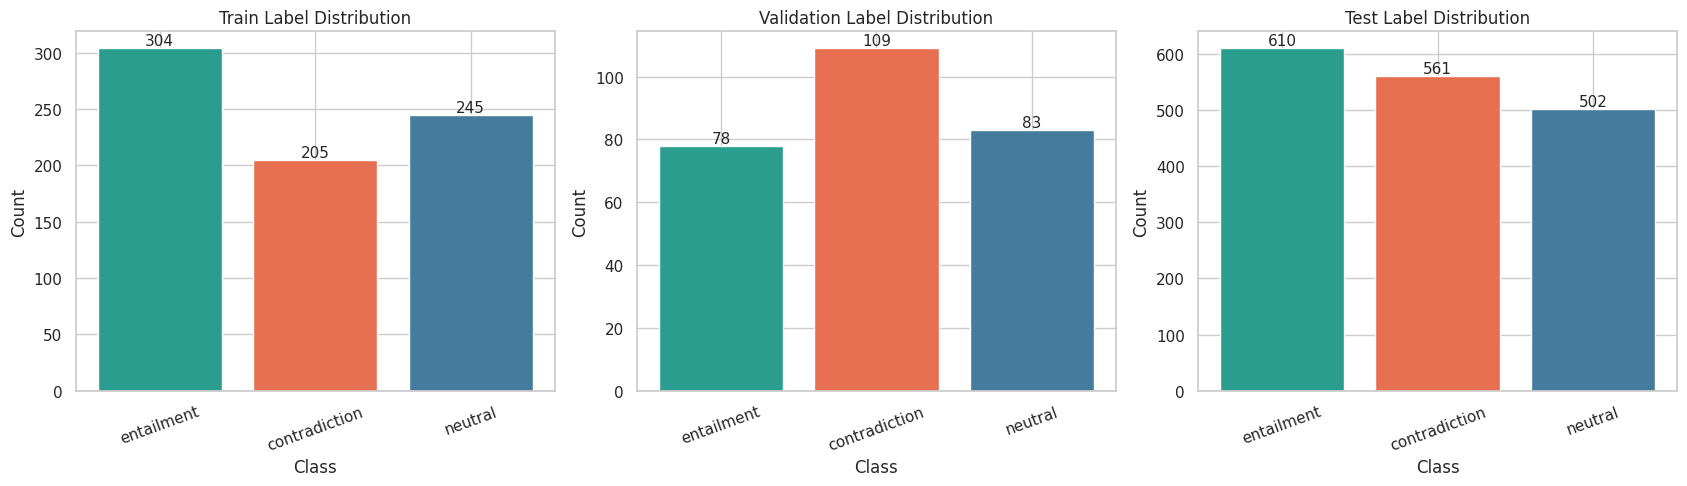

In [48]:
def plot_label_distribution(train_df, valid_df, test_df):
    split_data = {
        "Train": train_df,
        "Validation": valid_df,
        "Test": test_df
    }

    colors = ["#2A9D8F", "#E76F51", "#457B9D"]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for ax, (split_name, split_df) in zip(axes, split_data.items()):
        counts = split_df["label"].value_counts().sort_index()
        values = [counts.get(i, 0) for i in range(3)]

        bars = ax.bar(target_names, values, color=colors)
        ax.set_title(f"{split_name} Label Distribution")
        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=20)

        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                str(int(height)),
                ha="center",
                va="bottom"
            )

    plt.tight_layout()
    plt.show()


plot_label_distribution(train_df, valid_df, test_df)


In [50]:
MAX_LENGTH = 256

class NLIDataset(TorchDataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.premises = dataframe["premise"].tolist()
        self.hypotheses = dataframe["hypothesis"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.premises[idx],
            self.hypotheses[idx],
            truncation=True,
            max_length=self.max_length
        )

        encoding["labels"] = int(self.labels[idx])

        return encoding


In [51]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }


In [52]:
def train_and_evaluate_model(model_name, model_path, output_dir):
    print("=" * 80)
    print(f"Starting model: {model_name}")
    print(f"Model path: {model_path}")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=3
    )

    model.config.label2id = {
        "entailment": 0,
        "contradiction": 1,
        "neutral": 2
    }

    model.config.id2label = {
        0: "entailment",
        1: "contradiction",
        2: "neutral"
    }

    model.to(device)

    train_dataset = NLIDataset(train_df, tokenizer, MAX_LENGTH)
    valid_dataset = NLIDataset(valid_df, tokenizer, MAX_LENGTH)
    test_dataset = NLIDataset(test_df, tokenizer, MAX_LENGTH)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=25,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    train_output = trainer.train()

    eval_results = trainer.evaluate(valid_dataset)
    test_results = trainer.evaluate(test_dataset)

    predictions_output = trainer.predict(test_dataset)

    y_true = predictions_output.label_ids
    y_pred = np.argmax(predictions_output.predictions, axis=-1)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    result = {
        "model_name": model_name,
        "model_path": model_path,
        "trainer": trainer,
        "train_output": train_output,
        "eval_results": eval_results,
        "test_results": test_results,
        "classification_report_dict": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "log_history": trainer.state.log_history
    }

    save_path = os.path.join(output_dir, "final_model")
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    print(f"Finished model: {model_name}")
    print(f"Saved to: {save_path}")

    del trainer
    del model
    del tokenizer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


In [56]:
def train_and_evaluate_model(model_name, model_path, output_dir):
    print("=" * 80)
    print(f"Starting model: {model_name}")
    print(f"Model path: {model_path}")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=3
    )

    model.config.label2id = {
        "entailment": 0,
        "contradiction": 1,
        "neutral": 2
    }

    model.config.id2label = {
        0: "entailment",
        1: "contradiction",
        2: "neutral"
    }

    model.to(device)

    train_dataset = NLIDataset(train_df, tokenizer, MAX_LENGTH)
    valid_dataset = NLIDataset(valid_df, tokenizer, MAX_LENGTH)
    test_dataset = NLIDataset(test_df, tokenizer, MAX_LENGTH)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=25,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    train_output = trainer.train()

    eval_results = trainer.evaluate(valid_dataset)
    test_results = trainer.evaluate(test_dataset)

    predictions_output = trainer.predict(test_dataset)

    y_true = predictions_output.label_ids
    y_pred = np.argmax(predictions_output.predictions, axis=-1)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    result = {
        "model_name": model_name,
        "model_path": model_path,
        "trainer": trainer,
        "train_output": train_output,
        "eval_results": eval_results,
        "test_results": test_results,
        "classification_report_dict": report_dict,
        "classification_report_text": report_text,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "log_history": trainer.state.log_history
    }

    save_path = os.path.join(output_dir, "final_model")
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    print(f"Finished model: {model_name}")
    print(f"Saved to: {save_path}")

    del trainer
    del model
    del tokenizer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


In [54]:
models_to_compare = [
    {
        "model_name": "Base FaBERT",
        "model_path": "sbunlp/fabert",
        "output_dir": "/kaggle/working/base-fabert-parsinlu-entailment"
    },
    {
        "model_name": "KG-enhanced FaBERT",
        "model_path": "/kaggle/input/notebooks/aabdollahii/12-better-fabert-finetuned/fabert_kg_mlm",
        "output_dir": "/kaggle/working/kg-fabert-parsinlu-entailment"
    }
]


In [ ]:
all_results = {}

for model_info in models_to_compare:
    result = train_and_evaluate_model(
        model_name=model_info["model_name"],
        model_path=model_info["model_path"],
        output_dir=model_info["output_dir"]
    )

    all_results[model_info["model_name"]] = result


In [ ]:
comparison_rows = []

for model_name, result in all_results.items():
    test_results = result["test_results"]
    report = result["classification_report_dict"]

    comparison_rows.append({
        "model": model_name,
        "test_loss": test_results.get("eval_loss"),
        "test_accuracy": test_results.get("eval_accuracy"),
        "test_macro_f1": test_results.get("eval_macro_f1"),
        "test_macro_precision": test_results.get("eval_macro_precision"),
        "test_macro_recall": test_results.get("eval_macro_recall"),
        "entailment_f1": report["entailment"]["f1-score"],
        "contradiction_f1": report["contradiction"]["f1-score"],
        "neutral_f1": report["neutral"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

display(comparison_df)


In [ ]:
base_row = comparison_df[comparison_df["model"] == "Base FaBERT"].iloc[0]
kg_row = comparison_df[comparison_df["model"] == "KG-enhanced FaBERT"].iloc[0]

improvement = {
    "accuracy_improvement": kg_row["test_accuracy"] - base_row["test_accuracy"],
    "macro_f1_improvement": kg_row["test_macro_f1"] - base_row["test_macro_f1"],
    "macro_precision_improvement": kg_row["test_macro_precision"] - base_row["test_macro_precision"],
    "macro_recall_improvement": kg_row["test_macro_recall"] - base_row["test_macro_recall"],
    "entailment_f1_improvement": kg_row["entailment_f1"] - base_row["entailment_f1"],
    "contradiction_f1_improvement": kg_row["contradiction_f1"] - base_row["contradiction_f1"],
    "neutral_f1_improvement": kg_row["neutral_f1"] - base_row["neutral_f1"]
}

improvement_df = pd.DataFrame([improvement])

display(improvement_df)

if improvement["macro_f1_improvement"] > 0:
    print("KG-enhanced FaBERT improved over Base FaBERT based on Test Macro-F1.")
elif improvement["macro_f1_improvement"] < 0:
    print("KG-enhanced FaBERT did not improve over Base FaBERT based on Test Macro-F1.")
else:
    print("KG-enhanced FaBERT and Base FaBERT achieved the same Test Macro-F1.")


In [ ]:
metrics_to_plot = [
    "test_accuracy",
    "test_macro_f1",
    "test_macro_precision",
    "test_macro_recall"
]

plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x="metric",
    y="score",
    hue="model",
    palette=["#457B9D", "#E76F51"]
)

plt.ylim(0, 1)
plt.title("Base FaBERT vs KG-enhanced FaBERT on Parsinlu Entailment")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [ ]:
class_f1_metrics = [
    "entailment_f1",
    "contradiction_f1",
    "neutral_f1"
]

class_plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=class_f1_metrics,
    var_name="class",
    value_name="f1_score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=class_plot_df,
    x="class",
    y="f1_score",
    hue="model",
    palette=["#457B9D", "#E76F51"]
)

plt.ylim(0, 1)
plt.title("Per-Class F1 Comparison")
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [ ]:
for model_name, result in all_results.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(result["classification_report_text"])


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model_name, result) in zip(axes, all_results.items()):
    cm = result["confusion_matrix"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()
